# ContextFilter

**This application is based on the work of an MVP _(Minimum Viable Product)_ for the Data Product Design subject of my degree in Applied Data Science.**  
*Esta aplicación está basada en el trabajo de un MVP _(Minimum Viable Product)_ para la asignatura de Diseño de Producto de Datos de mi grado en Ciencia de Datos Aplicada.*  
*Aquesta aplicació està basada en el treball d'un MVP _(Minimum Viable Product)_ per l'assignatura de Disseny de Producte de Dades del meu grau en Ciència de Dades Aplicada.*  

**By default it is a toxic content flag, but it can be applied to any other content, even in a combined way.**  
*Por defecto es un marcador de contenido tóxico, pero se puede aplicar a cualquier otro contenido, incluso de manera combinada.*  
*Per defecte és un marcador de contingut tòxic, peró es pot aplicar a qualsevol altre contingut, inclús de manera combinada.*  

**Dataset credits:** Toxicity evaluation data were obtained from the [Jigsaw Toxic Comment Classification Challenge (Kaggle)](https://github.com/praj2408/Jigsaw-Toxic-Comment-Classification) and the associated GitHub repository by [Prajwal Krishna](https://github.com/praj2408). Many thanks for making these resources publicly available.  
**Créditos del conjunto de datos:** Los datos utilizados para la evaluación de toxicidad proceden del reto [Jigsaw Toxic Comment Classification Challenge (Kaggle)](https://github.com/praj2408/Jigsaw-Toxic-Comment-Classification) y del repositorio asociado en GitHub de [Prajwal Krishna](https://github.com/praj2408). Muchas gracias por poner estos recursos a disposición de la comunidad.  
**Crèdits del conjunt de dades:** Les dades utilitzades per a l'avaluació de toxicitat provenen del repte [Jigsaw Toxic Comment Classification Challenge (Kaggle)](https://github.com/praj2408/Jigsaw-Toxic-Comment-Classification) i del repositori associat a GitHub de [Prajwal Krishna](https://github.com/praj2408). Moltes gràcies per posar aquests recursos a disposició de la comunitat.


## Table of Contents / Tabla de contenidos / Taula de continguts
- [Construction of the MVP / Construcción del MVP / Construcció del MVP](#construcció-del-mvp)
  - [Loading libraries / Carga de librerías / Càrrega de llibreries](#càrrega-de-llibreries)
  - [Server creation / Creación del servidor / Creació del servidor](#creacio)
  - [Individual review calls / Llamadas a reseñas individualmente / Crides a ressenyes individualment](#crides-a-ressenyes-individualment)
  - [Server calls sending files / Llamadas al servidor enviando archivos / Crides al servidor fent enviament de fitxers](#crides-al-servidor-fent-enviament-de-fitxers)

## Construction of the MVP / Construcción del MVP / Construcció del MVP <a id="construcció-del-mvp"></a>


### Loading libraries / Carga de librerías / Càrrega de llibreries <a id="càrrega-de-llibreries"></a>   

The notebook is executed using **Python 3.12** and, following the professor's recommended approach, the models are executed through _Transformers pipelines_, which run directly on the local machine without relying on external APIs.

- Main libraries for natural language processing and model execution:
  - **Transformers** for loading and executing language models through zero-shot classification pipelines.
  - **PyTorch** as the model execution framework, enabling GPU acceleration when available.

- Libraries used occasionally, for example:
  - **pydantic and typing** to provide strong typing support within the language.
  - **fastapi** for straightforward API creation and **uvicorn** for server management. It also includes the required tools for asynchronous execution and event loop management.
  - **tinydb** for maintaining an operation log.
  - **langdetect and deep-translator** for language detection and translation.

- Libraries for visualizations and dynamic notebook execution:
  - **ipywidgets** and **display** components.

- Common libraries from the Python ecosystem:
  - **numpy, pandas, matplotlib...** for data processing, manipulation, and visualization.
  - **scikit-learn, matplotlib, and seaborn** for data analysis and metric evaluation *(see metrics notebook)*.
  - And the internally developed project libraries.

---

El notebook está ejecutado sobre **Python 3.12** y, gracias a las recomendaciones de enfoque del profesor, los modelos se ejecutan mediante _pipelines de Transformers_, que se utilizan directamente desde la propia máquina, sin depender de APIs externas.

- Librerías principales para el procesamiento del lenguaje natural y la ejecución de modelos:
  - **Transformers** para la carga y ejecución de modelos de lenguaje mediante pipelines de clasificación zero-shot.
  - **PyTorch** como framework de ejecución de los modelos, permitiendo aprovechar la aceleración mediante GPU cuando está disponible.

- Librerías utilizadas de forma puntual, por ejemplo:
  - **pydantic y typing** para obtener un tipado fuerte en el lenguaje.
  - **fastapi** para la creación de APIs de forma sencilla y **uvicorn** para gestionar el servidor. También las herramientas necesarias para la ejecución asíncrona y la gestión de loops.
  - **tinydb** para mantener un registro de las operaciones.
  - **langdetect y deep-translator** para detectar y convertir idiomas.

- Librerías para visualizaciones y ejecuciones dinámicas dentro del notebook:
  - **ipywidgets** y los elementos de **display**.

- Librerías habituales del ecosistema Python:
  - **numpy, pandas, matplotlib...** para el tratamiento, manipulación y visualización de datos.
  - **scikit-learn, matplotlib y seaborn** para el análisis de datos y la obtención de métricas *(ver notebook de métricas)*.
  - Y las librerías incorporadas internamente en el proyecto.

---

El notebook està executat sobre **Python 3.12** i, gràcies als consells d'enfocament del professor, els models s'executen mitjançant _pipelines de Transformers_, que s'utilitzen directament des de la pròpia màquina, sense dependència d'APIs externes.

- Llibreries principals per al processament del llenguatge natural i l'execució dels models:
  - **Transformers** per a la càrrega i execució dels models de llenguatge mitjançant pipelines de classificació zero-shot.
  - **PyTorch** com a framework d'execució dels models, permetent l'aprofitament de l'acceleració per GPU quan està disponible.

- Llibreries que faig servir de manera puntual, per exemple:
  - **pydantic i typing** per obtenir un tipatge fort en el llenguatge.
  - **fastapi** per a la creació d'APIs de manera senzilla i **uvicorn** per gestionar el servidor. També les eines necessàries per a l'execució asíncrona i la gestió de loops.
  - **tinydb** per mantenir un registre de les operacions.
  - **langdetect i deep-translator** per detectar i convertir idiomes.

- Llibreries per a visualitzacions i execucions dinàmiques dins del notebook:
  - **ipywidgets** i els elements de **display**.

- Llibreries habituals de l'ecosistema Python:
  - **numpy, pandas, matplotlib...** per al tractament, manipulació i visualització de dades.
  - **scikit-learn, matplotlib i seaborn** per a l'anàlisi de dades i l'obtenció de mètriques *(veure notebook de mètriques)*.
  - I les llibreries incorporades internament al projecte.


### Important / Importante /Important

>**Since the *torch* library (PyTorch) is also used; if you have an accelerator card, use the most appropriate version. In my case, CUDA 12.**
>
>*Como que también se utiliza la librería **torch** (PyTorch), si tenéis tarjeta aceleradora, utilizad la versión más adecuada. En mi caso, CUDA 12.*  
>
>*Com que també es fa servir la llibería **torch** (PyTorch), si teniu targeta acceledadora, feu servir la versió més adient. En el meu cas, CUDA 12.*

In [1]:
from transformers import pipeline
import torch

# en: It seems that with optional we can specify types and allow nulls
# es: Se ve que con optional podemos especificar tipos y permitir nulos
# ca: Es veu que amb optional podem tipar i permetre nuls

from typing import List, Dict, Optional

# en: of course, we load pydantic
# es: por supuesto, cargamos pydantic
# ca: per suposat, carreguem pydantic

from pydantic import BaseModel
import numpy as np
import pandas as pd
from datetime import datetime as dtt
from IPython.display import HTML, clear_output, display

# en: to save records
# es: para guardar registros
# ca: per guardar registres

from tinydb import TinyDB as tdb

# en: to manipulate languages
# es: para manipular idiomas
# ca: per manipular idiomes

from langdetect import detect
from deep_translator import GoogleTranslator

# en: now with fast-api and its possible modules
# es: ahora con fast-api y sus módulos posibles
# ca: ara amb fast-api amb els moduls possibles

from fastapi import FastAPI, Request, Header, \
     HTTPException, Body, Query, Form, File, UploadFile

# en: For file returns
# es: Para los retornos de archivo
# ca: Pels retorns de fitxer

from fastapi.responses import JSONResponse, StreamingResponse

# en: To load forms, python-multipart needs to be installed
# es: Para cargar formularios hace falta instalar python-multipart
# ca: Per carregar formularis fa falta instalar python-multipart


# en: for asynchronous execution and with loops
# es: para la ejecución asíncrona y con bucles
# ca: per a la execucio asíncrona i amb loops

import asyncio, nest_asyncio
import uvicorn
from threading import Thread

# en: if it is not too large, we will load ipywidgets
# es: si no es muy grande cargaremos los ipywidgets
# ca: si no es molt gran carregarem els ipywidgets

import ipywidgets as ipyw

# en: I also load requests to test it synchronously first
# es: también cargo requests para probarlo síncronamente primero
# ca: també carrego requests per provar-ho síncronament primer

import requests

# en: to encode calls
# es: para codificar llamadas
# ca: per fer encoding de crides

from urllib.parse import quote, urlencode

# en: import time to make pauses
# es: import time para hacer pausas
# ca: import time per fer pauses

import time

# en: to work with paths and files
# es: para trabajar con rutas y archivos
# ca: per treballar amb les rutes i fitxers

import os
import io


**Initial variables**  
*Variables iniciales*  
*Variables inicials*  

In [2]:
# en: I make it wait so that the libraries load correctly
#     sometimes, at startup it causes problems especially if they are large
#
# es: hago que espere para que se carguen bien las librerías
#     a veces, al inicio da problemas sobre todo si son grandes
#
# ca: faig que esperi perquè es carreguin be les llibreries
#     de vegades, d'inici dona problemes sobretot si son grans

time.sleep(2)

# en: base URL
# es: URL base
# ca: URL base

laUrl= "http://127.0.0.1:8000/"

# en: For file calls
#     I prepare a set with the allowed extensions, in the future others could be added to work
#     with excel-like files
#
# es: Para llamadas de archivos
#     Preparo un conjunto con las extensiones que permito, en un futuro se podrían añadir para operar
#     con archivos tipo excel
#
# ca: Per crides de fitxers
#     Preparo un set amb les extensions que permeto, en un futur es podrien afegir per operar
#     amb fitxers tipus excel
extPERMESES = {'.csv', '.txt', '.json'}

# en: Limit number of records per file, depends on the tests to be made,
#     but they can affect server performance
#
# es: Número límite de registros por archivo, depende de las pruebas que se quieran realizar,
#     pero pueden afectar al rendimiento del servidor
#
# ca: Nombre limit de registres per fitxer, depén de les proves que es vulgun fer,
#     però poden afectar al rediment del servidor

maxRegistres=5000

# en: Initial list of pairs to check toxicity (used by default)
# es: Lista de parejas inicial para comprobar toxicidad (uso por defecto)
# ca: Llista de parelles inicial per comprovar toxicitat (us per defecte)

llista_base = [

    # 🔴 LINGUISTIC TOXICITY
    ("insult", "respectful comment"),
    ("offensive language", "appropriate language"),
    ("personal attack", "constructive criticism"),
    ("aggressive", "neutral"),
    ("disrespectful", "polite"),
    ("hate", "opinion"),

    # 🔴 EXPLICIT INSULT
    ("this text contains insults", "this text is respectful"),
    ("rude comment", "polite comment"),

    # 🟡 QUALITY / SPAM
    ("coherent text", "nonsense text"),
    ("useful comment", "spam or irrelevant content")
]

# en: Threshold to consider whether to flag or not
# es: Umbral para considerar si se debe marcar o no
# ca: Llindar per considerar si s'ha de marcar o no

thershold_base=0.65

# en: The model to use  
# es: El modelo a utilizar  
# ca: El model a utilitzar  

el_model = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"

 # en: The device to use  
 # es: El dispositivo a utilizar  
 # ca: El dispositiu a utilitzar  

dispositiu = 0 if torch.cuda.is_available() else -1 

# en: The database that serves as a log of query executions on reviews (a log).
# es: La base de datos que sirve de registro de ejecuciones de consultas de reseñas (un log).
# ca: La base de dades que serveix de registre d'execucions de consultes de ressenyes (un log).

reg_ressenyes = tdb('reg_ressenyes.json')


We load the **Multilingual mDeBERTa-v3-base-mnli-xnli** model  

*Cargamos el modelo **Multilingual mDeBERTa-v3-base-mnli-xnli***  
*Carreguem el model **Multilingual mDeBERTa-v3-base-mnli-xnli***  

In [3]:
classificador_zero_shot = pipeline(
    "zero-shot-classification",
    model= el_model,
    device= dispositiu, 
    batch_size=16
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

**I generate the evaluator for a single review. In this case, it checks if it's in English, and if not, it's automatically translated.**

*Genero el evaluador para una sola reseña. En este caso se comprueba si viene en el idioma inglés y si no es así se traduce automáticamente.*  
*Genero l'avaluador per una sola ressenya. En aquest cas es comprova si ve en l'idioma anglès i si no és així es tradueix automàticament.*

In [4]:
# en: First we prepare the function to obtain (if necessary) the text translated into English
# es: Primero preparamos la función para obtener (si es necesario) el texto traducido al inglés
# ca: Primer preparem la funció per obtenir (si cal) el text traduït a l'anglès

def eval_lang(text:str) -> str:
    # en: Since the maximum length of the detector is 5000 characters,
    #     we will threshold it at 4500 characters at most just in case.
    #
    # es: Como la máxima longitud del detector es de 5000 caracteres,
    #     le aplicaremos un umbral de como máximo 4500 caracteres por si acaso.
    #
    # ca: Com que la màxima longitud del detector és de 5000 caràcters,
    #     el thersholdarem com a molt a 4500 caràcters per si de cas.

    text_trimat = text[:4500]
    
    try:
        lang = detect(text_trimat)
    except Exception as e:
        print(f"Language detection error \\ Error en la detección de idioma \\ Error en la detecció d'idioma {e}")
        lang = "en"

    # en: if the detected language is not English, we translate it to English.
    # es: si el idioma detectado no es el inglés, lo traducimos al inglés.
    # ca: si l'idioma detectat no és l'anglès, el traduïm a l'anglès.

    return text if lang == "en" else GoogleTranslator(source='auto', target='en').translate(text_trimat)

# en: Now, the individual evaluator function
# es: Ahora ya, la función evaluadora individual
# ca: Ara ja, la funció avaluadora individual

def avalua(ressenya: str, llista = llista_base, thershold=thershold_base) -> Dict[str, object]:
    resultat={}
    valors=[]
    resultat['success'] = True

    try:
        # en: Check if threshold is a value between 0 and 1
        # es: Compruebo si el umbral es un valor entre 0 y 1
        # ca: Comprovo si thershold es un valor entre 0 i 1

        threshold = float(thershold)
        if not isinstance(threshold, float) or threshold<0 or threshold>1:
            raise Exception(f"El valor de threshold{threshold} no és un valor entre 0 i 1")
        for parella in llista:
            # en: Check if the pair is a list or tuple of 2 elements
            # es: Compruebo si la pareja es una lista o tupla de 2 elementos
            # ca: Comprovo si la parella és una llista o tuple de 2 elements

            if not isinstance(parella, (list, tuple)) or len(parella)!=2:
                raise Exception(f"La parella {parella} no és una llista o tuple de 2 elements")
            pass

            # en: force it to be a list (in case it comes from a tuple)
            # es: fuerzo a que sea una lista (por si viene de una tupla)
            # ca: forço a que sigui una llista (per si ve d'una tupla)

            candidats = list(parella)

            # en: The target will be the score of the first element of the candidates
            # es: El objetivo será la puntuación del primer elemento de los candidatos
            # ca: L'objectiu serà la puntuació del primer element dels candidats

            objectiu = candidats[0]

            # en: Search for the classification for these candidates, forcing choice among the candidates
            # es: Busco la clasificación para estos candidatos, forzando elección entre los candidatos
            # ca: Busco la classificació per aquests candidats, forçant tria entre els candidats

            retorn = classificador_zero_shot(eval_lang(ressenya), candidats, multi_label=False)
            
            # en: try to find the text score for the target
            # es: intento encontrar la puntuación del texto para el objetivo
            # ca: miro de trobar la puntuació del text per l'objectiu

            try:
                index_objectiu = retorn['labels'].index(objectiu)
                score = retorn['scores'][index_objectiu]
                valors.append(score)
            except (ValueError, KeyError, IndexError) as e:
                # en: If I do not find the score, I set it to 0.5
                # es: Si no encuentro la puntuación, la dejo en 0.5
                # ca: Si no trobo la puntuació, la deixo en 0.5

                valors.append(0.5)
        # en: calculate the final score by taking the median
        #     and save each of the parameters and the verdict.
        #
        # es: calculo la puntuación final haciendo la mediana
        #     y guardo cada uno de los parámetros y el veredicto.
        #
        # ca: calculo la puntuacio final fent la mediana
        #     i guardo cadascun dels parametres i el veredicte.

        # en: Round to 2 decimal places
        # es: Redondeo a 2 decimales
        # ca: Arrodoneixo a 2 decimals

        resultat['score'] = round(float(np.median(valors)),2)
        resultat['thershold'] = thershold
        resultat['is_flagged'] = True if resultat['score'] >= thershold else False

    except Exception as e:
        resultat['success'] = False
        resultat['error'] = str(e)

    # en: add list to save it but not return it
    # es: añado la lista para guardarla pero no retornarla
    # ca: afegeixo llista per guardar-la però no retornar-la

    # en: I also return the values separately
    # es: los valores también los devuelvo aparte
    # ca: els valors també els torno apart

    return resultat, llista, valors
    

### Server creation / Creación del servidor / Creació del servidor <a id="creacio"></a>

The data will have to be sent in POST format (or in the visual environment)

besides a *header* called *tokenId* ...  
...they must include a query format directly, or data, where we would send form parts

**For a single query:**  
- ressenya: str *Review (REQUIRED)*  
- llista: list of 2-element lists or tuples
- thershold: coefficient between 0 and 1
- afegeix: indicates whether the list should be appended to the default list

**To send a file:**  
- Instead of the review, the file itself (and path if necessary). *(REQUIRED)*
- header: Indicates whether the file has a header or not (by default .csv files do and .txt files do not)
- retorn: which can be "score", "is_flagged", "both"
- laLlista: list of 2-element lists or tuples
- afegeix: indicates whether the list should be appended to the default list
- thershold: coefficient between 0 and 1
---
Los datos se tendrán que enviar en formato POST (o bien en el entorno visual)

además de un *header* llamado *tokenId* ...  
...tendrán que incluir un formato query directamente, o data, donde enviaríamos partes de formulario

**Para una consulta única:**  
- ressenya: str *Reseña (OBLIGATORIO)*  
- llista: lista de listas de 2 elementos o tuplas
- thershold: coeficiente entre 0 y 1
- afegeix: indica si la lista se debe anexar a la lista predeterminada

**Para enviar un archivo:**  
- En lugar de la reseña, el archivo (y ruta si es necesario) propiamente dicho. *(OBLIGATORIO)*  
- header: Indica si el archivo lleva cabecera o no (por defecto los .csv sí y los .txt no)
- retorn: que puede ser "score", "is_flagged", "both"
- laLlista: lista de listas de 2 elementos o tuplas
- afegeix: indica si la lista se debe anexar a la lista predeterminada
- thershold: coeficiente entre 0 y 1
---
Les dades s'hauran d'enviar en format POST (o bé en l'entorn visual)

a banda d'un _header_ anomenat _tokenId_ ...   
...hauràn d'incloure un format query directament, o data, on enviariem parts de formulari)  

**Per una consulta única:**  
- ressenya: str _(OBLIGATORI)_  
- llista: llista de llistes de 2 elements o tuples  
- thershold: coeficient entre 0 i 1
- afegeix: indica si la llista s'ha d'annexar a la llista predeterminada  

**Per enviar un fitxer:**  
- Enlloc de la ressenya, el fitxer (i ruta si cal) pròpiament dit. _(OBLIGATORI)_
- header: Indica si el fitxer porta capcelera o no (per defecte els .csv sí i els .txt no)
- retorn: que pot ser "score", "is_flagged", "both"
- laLlista: llista de llistes de 2 elements o tuples
- afegeix: indica si la llista s'ha d'annexar a la llista predeterminada  
- thershold: coeficient entre 0 i 1


<br>

**We prepare the call to the API (we make it with FastAPI)**  
*Preparamos la llamada a la API (la hacemos con FastAPI)*  
*Preparem la crida a l'API (la fem amb FastAPI)*  

In [5]:
# en: so that it works correctly and I can control the server from here...
# es: para que funcione bien y pueda controlar el servidor desde aquí...
# ca: perquè funcioni bé i pugui controlar el servidor des d'aqui...

nest_asyncio.apply()

# en: Load Fastapi!!! (ContextFilter)
# es: ¡¡¡Cargo Fastapi!!! (ContextFilter)
# ca: Carrego el Fastapi!!! (ContextFilter)

contextF = FastAPI()
# en: and to be able to make nested asynchronous calls
# es: y para poder hacer llamadas asíncronas anidadas
# ca: i per poder fer crides asincrones anidades

nest_asyncio.apply()

servidor_fil = None
servidor_loop = None
servidor = None

# en: I make a 'dummy' dictionary of clients to be able to call the API
#     if it were a real client, it should have an ID and a name,
#     more robust tokens with validity dates
#
# es: creo un diccionario 'dummy' de clientes para poder llamar a la API
#     si fuera un cliente real, debería tener un ID y un nombre,
#     unos tokens más robustos y con fechas de vigencia
#
# ca: faig un diccionari 'dummy' de clients per poder cridar l'API
#     si fos un client real, hauria de tenir un ID i un nom,
#     uns tokens més robustos i amb dates de vigència

clients = {'x001b3':'ContextFilter', 'xb10100':'ContextTest'}

# en: function to validate extensions (returns if it is one of them)
# es: función para validar las extensiones (retorna si es una de ellas)
# ca: funció per validar les extensions (retorna si es una d'elles)

def validaExtensio(fitxer):
    _, ext = os.path.splitext(fitxer)
    # en:this could be done like this or
    #     ext2=file.split(".")[-1].lower()
    #     but this way I get the 2 parts in case I am interested
    #
    # es:esto se podía hacer así o
    #     ext2=archivo.split(".")[-1].lower()
    #     pero así obtengo las 2 partes por si me interesa
    #
    # ca: això es podia fer així o
    #     ext2=fitxer.split(".")[-1].lower()
    #     però així obtinc les 2 parts per si m'interessa

    return ext.lower() in extPERMESES

# en: validate the file type
# es: validamos el tipo de archivo
# ca: validem el tipus de fitxer

def llegeixFitxer(fitxer: UploadFile, header: bool):
    capcelera = header
    try:
        if fitxer.filename.endswith(".csv"):
            ressenyes = pd.read_csv(fitxer.file, header=None if capcelera == False else 0)
        elif fitxer.filename.endswith(".txt"):
            ressenyes = pd.read_csv(fitxer.file, header=0 if capcelera == True else None, sep="\t")
        elif fitxer.filename.endswith(".json"):
            # en: Each row must be a json-dictionary record
            # es: Cada fila debe ser un registro json-diccionario
            # ca: Cada fila ha de ser un registre json-dicccionari

            ressenyes = pd.read_json(fitxer.file, orient="records", lines=True)
        return ressenyes
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"Error llegint el fitxer: {str(e)}")
    
# en: convert the list from string format to list format if it exists
# es: convierto si existe la lista de formato string a formato list
# ca: converteixo si existeix la llista de format string a format list

def llegeix_llista(pllista: str,pafegeix: bool):
    try:
        for parella in eval(pllista):
            # en: check if the pair is a list or tuple of 2 elements
            # es: compruebo si la pareja es una lista o tupla de 2 elementos
            # ca: comprovo si la parella és una llista o tuple de 2 elements

            if not isinstance(parella, (list, tuple)) or len(parella)!=2:
                raise HTTPException(status_code=400,
                detail="Some of the pairs are not a list or a tuple of 2 elements " \
                    "/ Alguna de las parejas no es una lista o tupla de 2 elementos " \
                    "/ Alguna de les parelles no és una llista o tupla de 2 elements.")
        if pafegeix:
            return eval(pllista)+llista_base
        return eval(pllista)
    except Exception as e:
        raise HTTPException(status_code=400,
        detail="Error reading the list " \
            "/ Error leyendo la lista " \
            f"/ Error llegint la llista: {str(e)}.")

def validaRegistres(df):
    if df.shape[0] == 0:
        raise HTTPException(status_code=400,
        detail="Empty file, nothing can be evaluated " \
            "/ Archivo sin registros, no se puede evaluar nada " \
            "/ Fitxer sense registres, no es pot avaluar res.")
    elif df.shape[0] > maxRegistres:
        raise HTTPException(status_code=400,
        detail=f"The file has more than {maxRegistres} records " \
            f"/ El archivo tiene más de {maxRegistres} registros " \
            f"/ El fitxer té més de {maxRegistres} registres.")

def gravaError(resultat, tokenId):
    resultat['success'] = False
    resultat['client'] = clients[tokenId]
    clau=reg_ressenyes.insert(resultat)
    resultat['clau'] = clau
    return resultat


# en: to load and verify the query dictionary
#     we do it with BaseModel
#
# es: para cargar y verificar el diccionario de la llamada
#     lo hacemos con BaseModel
#
# ca: per carregar i verificar el diccionari de la crida
#     ho fem amb Basemodel

class missatgeModel(BaseModel):
    ressenya: Optional[str] = None
    llista: Optional[str] = None
    thershold: Optional[float] = None
    afegeix: Optional[bool] = False


# en: this is the endpoint to receive individual reviews
# es: este es el endpoint para recibir reseñas individuales
# ca: aquest és l'endpoint per rebre ressenyes individuals

@contextF.post("/verifica/")
async def verifica(consulta: Request,
    missatgeM: Optional[missatgeModel] = Body(default=None),
    ressenya: Optional[str] = Query(default=None),
    llista: Optional[str] = Query(default=None),
    thershold: Optional[float] = Query(default=None),
    afegeix: Optional[bool] = Query(default=None),
    tokenId: str = Header(...)):

    # en: convert it to dictionary
    # es: lo paso a diccionario
    # ca: ho passo a diccionari

    missatge = missatgeM.model_dump(exclude_none=True) if missatgeM else {}
    # en: and now I pass the variables that exist
    # es: y ahora le paso las variables que existan
    # ca: i ara li passo les variables que existeixin
    
    if ressenya is not None:
        missatge['ressenya'] = ressenya
    if llista is not None:
        missatge['llista'] = llista
    if thershold is not None:
        missatge['thershold'] = thershold
    if afegeix is not None:
        missatge['afegeix'] = afegeix

    if tokenId not in clients:
        raise HTTPException(status_code=401, detail="Unauthorized token / Token no autorizado / Token no autoritzat")

    resultat={}
    retorn=None

    try:       
        llista=llegeix_llista(missatge['llista'],missatge['afegeix']) if 'llista' in missatge else llista_base
                
        thershold=missatge['thershold'] if 'thershold' in missatge else thershold_base
        
        if 'ressenya' not in missatge:
            raise ValueError("Manca la ressenya")
        retorn=avalua(missatge['ressenya'], llista, thershold)
        resultat=retorn[0] # which is the actual result / que es el resultado real / que es el resultat real
    except Exception as e:
        resultat['success'] = False
        resultat['error'] = str(e)
    resultat['time']=dtt.now().strftime("%Y-%m-%d %H:%M:%S")
    if retorn!=None:
        clau=reg_ressenyes.insert(resultat|{'client': clients[tokenId], 'llista': retorn[1], 'valors': retorn[2]})
    else:
        clau=reg_ressenyes.insert(resultat|{'client': clients[tokenId]})
    # en: we should return the key
    # es: deberíamos retornar la clave
    # ca: hauriem de retornar la clau
    
    resultat['clau'] = clau
    return resultat|missatge

# en: this is the endpoint to receive files
# es: este es el endpoint para recibir archivos
# ca: aquest és l'endpoint per rebre fitxers

@contextF.post("/totDeCop/")
async def totDeCop(
    fitxer: UploadFile = File(...),
    header: Optional[bool] = Form(None),
    retorn: Optional[str] = Form(None),
    laLlista: Optional[str] = Form(None),
    afegeix: Optional[bool] = Form(False),
    thershold: Optional[float] = Form(thershold_base),
    tokenId: str = Header(...)
):

    # en: Start by preparing elements for log and return
    # es: Empiezo preparando elementos para registro y retorno
    # ca: Començo preparant elements per log i retorn

    resultat={}
    # en: Add base values to maintain order when returning results
    # es: Añado valores base para mantener el orden a la hora de retornar el resultado
    # ca: Afegeixo valors base per mantenir l'ordre a l'hora de retornar resultat

    resultat['success'] = True
    resultat['time']=dtt.now().strftime("%Y-%m-%d %H:%M:%S")
    resultat['client'] = 'Unknown / Desconocido/ Desconegut' # For now \ Por el momento \ De moment  

    if not validaExtensio(fitxer.filename):
        resultat['error'] = "File not valid. We accept types: .csv, .txt, .json " \
        "/ Archivo no válido. Aceptamos de tipo: .csv, .txt, .json " \
        "/ Fitxer no vàlid. Acceptem de tipus: .csv, .txt, .json"
        resultat = gravaError(resultat, tokenId)
        return JSONResponse(
            status_code=400,
            content=resultat
        )
    
    # en: Now I'll validate the return parameter (None's equivalent to 'both')
    # es: Ahora validaré el parámetro de retorno (None equival a 'both')
    # ca: Ara validaré el paràmetre de retorn (None equival a 'both')

    if retorn not in [None,"score", "is_flagged", "both"]:
        resultat['error'] = "Invalid return parameter. We accept: score, is_flagged, both " \
            "/ Parámetro de retorno no válido. Aceptamos: score, is_flagged, both" \
            " / Paràmetre de retorn no vàlid. Acceptem: score, is_flagged, both"
        resultat = gravaError(resultat, tokenId)
        return JSONResponse(
            status_code=400,
            content=resultat
        )
    if thershold < 0 or thershold > 1:
        resultat['error'] = "The cutoff coefficient must be between 0 and 1" \
        "/ El coeficiente de corte debe estar entre 0 y 1 " \
        "/ El coeficient de tall ha d'estar entre 0 i 1"
        resultat = gravaError(resultat, tokenId)
        return JSONResponse(
            status_code=400,
            content=resultat
        )
    
    if laLlista is None:
        laLlista = llista_base
    else:
        try:
            laLlista = llegeix_llista(laLlista,afegeix)
        except HTTPException as http_exc:
            resultat['error'] = http_exc.detail
            resultat = gravaError(resultat, tokenId)
            return JSONResponse(status_code=http_exc.status_code, content=resultat)


    try:
        ressenyes=llegeixFitxer(fitxer, header)
    except HTTPException as http_exc:
        resultat['error'] = http_exc.detail
        resultat = gravaError(resultat, tokenId)
        return JSONResponse(status_code=http_exc.status_code, content=resultat)  
    
    # en: If the file was read successfully, we check the number of records
    # es: Si el archivo se ha leído correctamente, comprobamos el número de registros
    # ca: Si el fitxer s'ha llegit correctament, comprovem el nombre de registres

    try:
        validaRegistres(ressenyes)
    except HTTPException as http_exc:
        resultat['error'] = http_exc.detail
        resultat = gravaError(resultat, tokenId)
        return JSONResponse(status_code=http_exc.status_code, content=resultat)
    
    # en: Now I process the texts
    # es: Ahora proceso los textos
    # ca: Ara processo els textos

    xllista=[]
    for x in laLlista:
        # en: force the first field to string
        # es: fuerzo el primer campo a string
        # ca: forço el primer camp a string

        result=classificador_zero_shot(ressenyes.iloc[:,0].astype(str).to_list(),x, multi_label=False)
        xllista.append([y['scores'][0] if y['labels'][0]==x[0] else y['scores'][1] for y in result ])
    xdf=pd.DataFrame(xllista)
    # en: mean and median are calculated by columns and a series is obtained as a result where each record is the mean or median of the column
    # es: se realiza la media y mediana por columnas y se obtiene una serie como resultado donde cada registro es la media o mediana de la columna
    # ca: es fa el mean i media per columnes i sobté una serie com  a resultat on cada registre és la mitjana o mediana de la columna

    xpuntuacions=xdf.median().round(2)
    if retorn in [None,"score","both"]:
        ressenyes['score']=xpuntuacions
    if retorn in [None,"is_flagged","both"]:
        ressenyes['is_flagged']=[True if y >=thershold else False for y in xpuntuacions]

    # en: Convert the dataframe to CSV (in memory) if everything went well 
    # es: Convertimos a CSV el dataframe (en memoria) si todo ha ido bien 
    # ca: Convertim a CSV el dataframe (en memòria)si tot ha anat bé 
    
    emisor = io.StringIO()
    ressenyes.to_csv(emisor, index=False)
    emisor.seek(0)
    
    return StreamingResponse(
        emisor,
        media_type="text/csv",
        headers={"Content-Disposition": "attachment; filename=evaluated.csv",
        "Result":"success", "records": str(ressenyes.shape[0]),
        "average_coefficient": str(xpuntuacions.mean().round(2)),
        "thershold": str(thershold),
        "flaggeds":str([True if y >=thershold else False for y in xpuntuacions].count(True))}
    )


**Preparing the server (uvicorn)**  
*Preparamos el servidor (uvicorn)*  
*Preparem el servidor (uvicorn)*  

In [6]:
# en: Separate the code for testing purposes
# es: Separo el código por cuestiones de las pruebas
# ca: Separo el codi per qüestions de les proves

def arrenca_contextF():
    # en: we refer to global variables
    # es: hacemos referencia a las variables globales
    # ca: fem referència a les variables globals
    
    global servidor_fil, servidor_loop, servidor

    if servidor_fil and servidor_fil.is_alive():
        info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl", "funcionament")
        return

    def arrenca_servidor():
        global servidor_loop, servidor
        config = uvicorn.Config(contextF, host="127.0.0.1", port=8000, log_level="error")
        servidor = uvicorn.Server(config)
        servidor_loop = asyncio.new_event_loop()
        asyncio.set_event_loop(servidor_loop)
        servidor_loop.run_until_complete(servidor.serve())

    servidor_fil = Thread(target=arrenca_servidor, daemon=True)
    servidor_fil.start()
    estat_ctl.value = actualitzar_ctls(idiomaActual,"estat_lbl", "funcionament", laUrl=laUrl)
    info_ctl.value= actualitzar_ctls(idiomaActual,"info_lbl", "iniciat")

def atura_ContextFilter():
    global servidor_loop, servidor

    if servidor and servidor.should_exit is False:
        info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl", "aturant")
        servidor.should_exit = True
        estat_ctl.value = actualitzar_ctls(idiomaActual,"estat_lbl", "aturat")
        info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl", "waiting")
    else:
        info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl", "inactiu")
        estat_ctl.value = actualitzar_ctls(idiomaActual,"estat_lbl", "aturat")


**Now the _widgets_ and the server startup part itself**  
*Ahora **los widgets** y la parte de arranque del servidor propiamente dicha*  
*Ara **els widgets** i la part d'arrencada del  servidor pròpiament dita*  

In [7]:
# en: Steps to update the language of the widgets
# es: Pasos para actualizar el idioma de los widgets
# ca: Passos per actualitzar l'idioma dels widgets

idiomaActual = 'English'
dpIdioma = ipyw.Dropdown(options=['English', 'Español', 'Català'],
    value=idiomaActual, description='Language / Idioma',style={'description_width': 'initial'})
from ipy_multil_mvm import languages, caches, actualitzar_ctls

In [8]:
bArrencar = ipyw.Button(description=languages[idiomaActual]["barrencar_desc"],button_style="success")
bAturar = ipyw.Button(description=languages[idiomaActual]["baturar_desc"],button_style="danger")
estat_ctl = ipyw.Label(value=actualitzar_ctls(idiomaActual,"estat_lbl", "API_off"))
info_ctl = ipyw.Label(value=actualitzar_ctls(idiomaActual,"info_lbl", "awaiting"),style={"font_style":"italic"})
controladora= ipyw.VBox([dpIdioma, ipyw.HBox([bArrencar,bAturar,estat_ctl]),info_ctl],
layout=ipyw.Layout(border="1px solid black",padding="10px",margin="10px"))

def actualitzar_idioma(idioma):
    global idiomaActual
    idiomaActual = idioma['new']
    bArrencar.description = languages[idiomaActual]["barrencar_desc"]
    bAturar.description = languages[idiomaActual]["baturar_desc"]
    estat_ctl.value = caches[idiomaActual]["estat_lbl"]
    info_ctl.value = caches[idiomaActual]["info_lbl"]
    ressenya_ctl.description = languages[idiomaActual]["review_desc"]
    ressenya_ctl.placeholder = languages[idiomaActual]["review_placeholder"]
    coef2_ctl.description = languages[idiomaActual]["threshold_desc"]
    coef2_ctl.placeholder = languages[idiomaActual]["threshold_placeholder"]
    llista2_ctl.description = languages[idiomaActual]["llista_desc"]
    llista2_ctl.placeholder = languages[idiomaActual]["llista_placeholder"]
    afegeix2_ctl.description = languages[idiomaActual]["add_desc"]
    enviar2_btn.description = languages[idiomaActual]["send_desc"]
    opcionsAddChk2.description = languages[idiomaActual]["opcions_ad_desc"]
    fitxer_label.value = caches[idiomaActual]["file"]
    coef_ctl.description = languages[idiomaActual]["threshold_desc"]
    coef_ctl.placeholder = languages[idiomaActual]["threshold_placeholder"]
    llista_ctl.description = languages[idiomaActual]["llista_desc"]
    llista_ctl.placeholder = languages[idiomaActual]["llista_placeholder"]
    afegeix_ctl.description = languages[idiomaActual]["add_desc"]
    enviar_btn.description = languages[idiomaActual]["send_file_desc"]
    opcionsAddChk.description = languages[idiomaActual]["opcions_ad_desc"]
    retorn_ctl.description = languages[idiomaActual]["retorn_desc"]

dpIdioma.observe(actualitzar_idioma, names="value")

**... and let's start!!**  
*... ¡¡y arrancamos!!*  
*... i arrequem!!*  

**This widget starts automatically, and as it receives information from API calls, it is possible that when the notebook is running, it has a message similar to this one:**  
*Este widget arranca automáticamente, y como va recibiendo información de llamadas a la API, es posible que cuando el notebook esté arrancado, tenga un mensaje similar a este:*  
*Aquest widget, arrenca automàticament, i com va rebent informació de crides a la API, és possible que quan el notebook estigui arrencat, tingui un missatge similar a aquest:*  

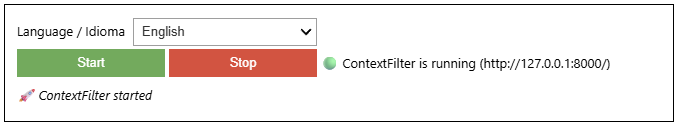


In [9]:

bArrencar.on_click(lambda b: arrenca_contextF())
bAturar.on_click(lambda b: atura_ContextFilter())

display(controladora)

**Really, ContextFilter is activated in the next cell, when the start button is _clicked_**  
*Realmente, ContextFilter se activa en la celda siguiente, cuando se _pulsa_ el botón de arrancar*  
*Realment, ContextFilter s'activa en la cel·la següent, quan _clica_ el botó d'arrencar*  

In [10]:
bArrencar.click()

### Call to reviews individually / Llamadas a reseñas individualmente / Crida a ressenyes individualment <a id="crides-a-ressenyes-individualment"></a>

**As I already mentioned, I had already started this part before beginning the challenge, as I was very clear about how my application should be. Therefore, I leave it to enjoy and be able to evaluate reviews individually.**  

*Como ya he comentado, esta parte ya la tenía iniciada antes de empezar el reto, ya que yo tenía muy claro cómo tenía que ser mi aplicación. Por lo tanto, la dejo para disfrutar y poder evaluar reseñas de manera individual.*  

*Com ja he comentat, aquesta part, ja la tenia iniciada abans de començar el repte, ja que jo tenia molt clar com havia de ser la meva aplicació. Per tant la deixo per disfrutar i poder avaluar ressenyes de manera individual.*

Call with **curl** / Llamada con **curl** / Crida amb **curl**  
 - Look at the call, the parameters while sending those the server needs, the return can be configured in many ways  
*(see the curl call to analyze files)*  

- Mirad la llamada, los parámetros mientras se envíen los que necesite el servidor, el retorno se puede configurar de muchas maneras
*(ver la llamada curl para analizar archivos)*  

-  Mireu la crida, els paràmetres mentre s'envii els que necessiti el servidor, el retorn es pot configurar de moltes maneres  
_(veure la crida curl per analitzar fitxers)_

In [11]:
curressenya=quote("Aquesta és una ressenya de prova")
curtokenId="x001b3"
cur_parametres=f'-X POST -H "tokenId: {curtokenId}"'\
    + f' "{laUrl}verifica/' \
    + f'?ressenya={curressenya}"'

display(HTML("<font size=3><b>Sample of the call with curl " \
"/ Muestra de la llamada con curl / Mostra de la crida amb curl</b></font>" \
+ f"<br><font size=2.5>curl {cur_parametres}</font>"))
sortida=!curl {cur_parametres}
display(sortida)
info_ctl.value = actualitzar_ctls(idiomaActual, "info_lbl", "curl")


['  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current',
 '                                 Dload  Upload  Total   Spent   Left   Speed',
 '',
 '  0      0   0      0   0      0      0      0                              0',
 '  0      0   0      0   0      0      0      0           00:01              0',
 '  0      0   0      0   0      0      0      0           00:02              0',
 '  0      0   0      0   0      0      0      0           00:03              0',
 '  0      0   0      0   0      0      0      0           00:04              0',
 '100    150 100    150   0      0     35      0   00:04   00:04             35',
 '100    150 100    150   0      0     35      0   00:04   00:04             35',
 '100    150 100    150   0      0     35      0   00:04   00:04             35',
 '{"success":true,"score":0.39,"thershold":0.65,"is_flagged":false,"time":"2026-06-16 19:57:29","clau":4,"ressenya":"Aquesta és una ressenya de prova"}']

**This would be another way to make the call *(in addition, this time in English)***  
*Esta sería otra manera de hacer la llamada (además, esta vez en inglés)*  
*Aquesta seria, una altra manera de fer la crida (a més, aquest cop en anglès)*

In [12]:
clear_output()
curtokenId="x001b3"
dictParametres={"ressenya":"Esta reseña es horrorosa"}

cur_parametres=f'-X POST -H "tokenId: {curtokenId}"'\
+ f' "{laUrl}verifica/?' \
    + f'{urlencode(dictParametres)}"'

display(HTML("<font size=3><b>Sample of the call with curl " \
"/ Muestra de la llamada con curl / Mostra de la crida amb curl</b></font>" \
+ f"<br><font size=2.5>curl {cur_parametres}</font>"))
sortida=!curl {cur_parametres}
display(sortida)
info_ctl.value = actualitzar_ctls(idiomaActual, "info_lbl", "curl")

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


['  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current',
 '                                 Dload  Upload  Total   Spent   Left   Speed',
 '',
 '  0      0   0      0   0      0      0      0                              0',
 '  0      0   0      0   0      0      0      0           00:01              0',
 '  0      0   0      0   0      0      0      0           00:02              0',
 '100    141 100    141   0      0     65      0   00:02   00:02             65',
 '100    141 100    141   0      0     65      0   00:02   00:02             65',
 '100    141 100    141   0      0     65      0   00:02   00:02             65',
 '{"success":true,"score":0.89,"thershold":0.65,"is_flagged":true,"time":"2026-06-16 19:57:31","clau":5,"ressenya":"Esta reseña es horrorosa"}']

Call with **requests** / Llamada con **requests** / Crida amb **requests**  
*Now, in Catalan / Ahora, en catalán / Ara, en català*

**This is an example of how to make the call directly inside a python script**  
***(I present the output a bit more 'pretty')***  
*Este es un ejemplo de cómo hacer la llamada directamente dentro de un script python*
*(presento la salida un poco más 'elegante')*  
_Aquest és un exemple de com fer la crida directament dins d'un script python_  
_(presento la sortida una mica més 'elegant')_

In [13]:
clear_output()
dict_json3={"ressenya": "Aquesta prova fa fàstic","ref": "123456789"}
resposta = requests.post(laUrl+"verifica/", json=dict_json3, headers={"tokenId": "x001b3"})
cadena="<font size=3><b>Sample of the requests call return " \
    "/ Muestra del retorno de la llamada requests " \
    "/ Mostra del retorn de la crida requests</b></font><br><br>"
for x,i in resposta.json().items():
    cadena+=f"<b>{x}:</b> {i}<br>"
display(HTML(cadena))
info_ctl.value = actualitzar_ctls(idiomaActual, "info_lbl", "requests")



Call with **ipywidgets** / Llamada con **ipywidgets** / Crida amb **ipywidgets**  

**This is a simulation of a call simulating an application.**  
**The 'complication' has been the number of controls to add, but I've been very surprised by the number of ways ipywidgets has to control, link, and interact elements with one another.**

*Esto es una simulación de una llamada simulando una aplicación.*  
*La 'complicación' ha sido la cantidad de controles a añadir, pero me he quedado muy sorprendido de la cantidad de maneras que tiene ipywidgets para controlar, vincular e interactuar unos elementos con otros.*

*Això és una simulació d'una crida simulant una aplicació.*  
*La 'complicació' ha estat la quantitat de controls a afegir, però m'he quedat molt sorprés de la quantitat de maneres que té ipywidgets per a controlar, vincular i interactuar uns elements amb els altres.*


**This widget should look like this once the notebook is run**  
*Este widget debería verse así una vez ejecutado el notebook*  
*Aquest widget s'hauria de veure així un cop executat el notebook*  

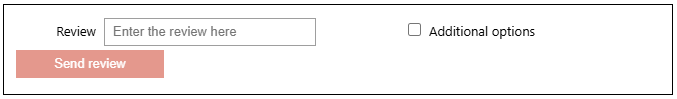

**And once a review is sent and received, it should look like this:**  
*Y una vez enviada y recibida una reseña, debería verse así:*  
*I un cop enviada i rebuda una ressenya, s'hauria de veure així:**

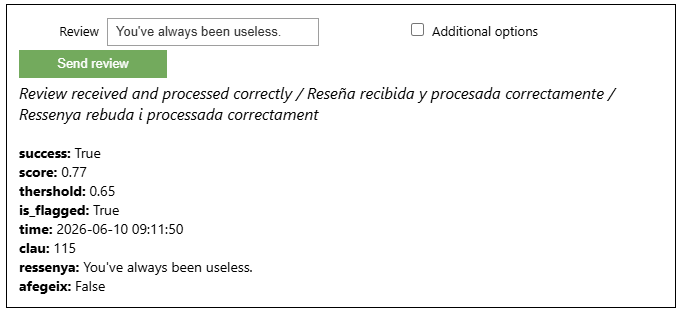


In [14]:
ressenya_ctl = ipyw.Text(value='', description=languages[idiomaActual]["review_desc"], placeholder=languages[idiomaActual]["review_placeholder"])
coef2_ctl = ipyw.Text(value='', description=languages[idiomaActual]["threshold_desc"], placeholder=languages[idiomaActual]["threshold_placeholder"])
llista2_ctl = ipyw.Text(value='', description=languages[idiomaActual]["llista_desc"], placeholder=languages[idiomaActual]["llista_placeholder"])
afegeix2_ctl = ipyw.Checkbox(value=False, description=languages[idiomaActual]["add_desc"], layout=ipyw.Layout(display='none'))

enviar2_btn = ipyw.Button(description=languages[idiomaActual]["send_desc"],disabled=True, button_style="danger")
info3_ctl = ipyw.Output()

opcionsAddChk2 = ipyw.Checkbox(value=False, description=languages[idiomaActual]["opcions_ad_desc"])
opcionsAddBox2 = ipyw.VBox([
    coef2_ctl,
    llista2_ctl,
    afegeix2_ctl,
],layout=ipyw.Layout(display='none'))

def opcionsAddChk2_canvia(change):
    if change.new:
        opcionsAddBox2.layout.display = ''
    else:
        opcionsAddBox2.layout.display = 'none'
        coef2_ctl.value = ''
        llista2_ctl.value = ''
        afegeix2_ctl.value = False

opcionsAddChk2.observe(opcionsAddChk2_canvia, names='value')

ressenyaBox = ipyw.HBox([
    ressenya_ctl,
    opcionsAddChk2,
])

def actualitzar_visibilitat_afegeix2_ctl(change):
    valor = llista2_ctl.value
    if not valor.strip():
        afegeix2_ctl.layout.display = 'none'
        afegeix2_ctl.value = False
    else:
        afegeix2_ctl.layout.display = ''

llista2_ctl.observe(actualitzar_visibilitat_afegeix2_ctl, names='value')

# Actualitzar label del fitxer
def actualitzar_ressenya(change):
    if ressenya_ctl.value.strip():
        enviar2_btn.disabled = False
        enviar2_btn.button_style = "success"
    else:
        enviar2_btn.disabled = True
        enviar2_btn.button_style = "danger"

ressenya_ctl.observe(actualitzar_ressenya, names='value')

def processar_ressenya(b):
    info3_ctl.clear_output()
    with info3_ctl:
        # en: We prepare data and make the call
        # es: Preparamos datos y hacemos la llamada
        # ca: Preparem dades i fem la crida

        dades = {
            "ressenya": ressenya_ctl.value.strip(),
            "tall": None if coef2_ctl.value.strip() == "" else float(coef2_ctl.value.strip()),
        }
        if llista2_ctl.value.strip():
            dades["llista"] = str(llista2_ctl.value.strip())
            dades["afegeix"] = afegeix2_ctl.value

        try:
            display(HTML("<font size=3><i>Waiting for response... / Esperando respuesta / Esperant resposta...</i></font>"))
            resposta = requests.post(laUrl+"verifica/",
                                     json=dades,
                                     headers={"tokenId": "x001b3"})
        except Exception as e:
            clear_output()
            print(f"Connection error/Error de conexión/Error de connexió: {e}")
            return

        if resposta.ok:
            clear_output()
            display(HTML("<font size=3><i>Review received and processed correctly / Reseña recibida y procesada correctamente / Ressenya rebuda i processada correctament</i></font>"))
            info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl", "ok")
        else:
            clear_output()
            display(HTML(f"<font size=3><i>Error: {resposta.status_code}</i><br></font>"))
            info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl", "error")
        cadena="<br>"
        for key, value in resposta.json().items():
            cadena+=f"<b>{key}:</b> {value}<br>"
        display(HTML(cadena))

enviar2_btn.on_click(processar_ressenya)

# en: We show the widget
# es: Mostramos el widget
# ca: Mostrem el widget

display(ipyw.VBox([
    ressenyaBox,
    opcionsAddBox2,
    enviar2_btn,
    info3_ctl
    ],layout=ipyw.Layout(border="1px solid black",padding="10px",margin="10px")))


### Server calls sending files / Llamadas al servidor enviando archivos / Crides al servidor fent enviament de fitxers <a id="crides-al-servidor-fent-enviament-de-fitxers"></a>

We will be requesting several files in several different ways; for now, only the sending of .csv, .txt, and .json is implemented.

* The parameters mentioned above can be requested (to change the list of tuples, the coefficient, the return...)
* Whichever file is sent, **the format of the return file will always be a .csv**.

---

Iremos solicitando varios archivos de varias formas diferentes; por el momento, solo está implementada la entrega de .csv, .txt y .json.

* Se pueden solicitar los parámetros ya mencionados anteriormente (para cambiar la lista de tuplas, el coeficiente, el retorno...)
* Sea cual sea el archivo enviado, **el formato del archivo de retorno siempre será un .csv**.  

---

Anirem demanant varis fitxers de vàries formes diferents, de moment, sols està implementat l'enviament de .csv, .txt i .json.  

- Es poden demanar els paràmetres ja ementats anteriorment, (per canviar la llista de tuples, el coeficient, el retorn...)
- Sigui quin sigui el fitxer enviat, **el format del fitxer de retorn sempre serà un .csv**.

**We will use several small test files prepared for this purpose**  
*Utilizaremos varios pequeños archivos de prueba preparados a tal efecto*  
*Utilitzarem diversos petits fitxers de prova preparats a tal efecte*

Call with **request**  

Just like before, this simulates code embedding within a script or notebook to request the Constructiva API to return the file once processed.

---

Llamada con **request**  

Igual que antes, simula una incrustación de código en un script o notebook para solicitar a la API de Constructiva que devuelva el archivo una vez procesado.

---

crida amb **request**  

Igual que abans, simula una incrustació de codi en un script o notebook, per demanar a la API de Constructiva que retorni el fitxer, un cop processat.

In [15]:
clear_output()
dades={}
elfitxer="data/en_1_10.csv"
if os.path.exists(elfitxer):
    with open(elfitxer, "rb") as f:
        fitxer = {"fitxer": (elfitxer, f)}
        resposta = requests.post(laUrl+"totDeCop/", files=fitxer, data=dades, headers={"tokenId": "x001b3"})
    if resposta.ok:
        info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl", "fich_ok",records=resposta.headers['records'],
        flagged=resposta.headers['flaggeds'],average_coefficient=resposta.headers['average_coefficient'])
        with open("data/evaluated.csv", "wb") as f:
            f.write(resposta.content)
    # en: If everything was ok, let's show the received file
    # es: Si todo ha ido bien, mostremos el archivo recibido
    # ca: Si tot ha anat bé, mostrem el fitxer rebut
        dfResposta=pd.read_csv("data/evaluated.csv")
        display(HTML("<font size=3><b>Sample of the received file " \
            + "/ Muestra del archivo recibido " \
            + "/ Mostra del fitxer rebut</b></font>"))
        display(dfResposta.head(10))
    else:
        info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl", "error_status", status_code=resposta.status_code)
else:
    info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl", "fnotfound", filename=elfitxer)

,comment_text,any_toxic,id,score,is_flagged
0,Explanation\nWhy the edits made under my usern...,False,0000997932d777bf,0.48,False
1,D'aww! He matches this background colour I'm s...,False,000103f0d9cfb60f,0.34,False
2,"Hey man, I'm really not trying to edit war. It...",False,000113f07ec002fd,0.64,False
3,"""\nMore\nI can't make any real suggestions on ...",False,0001b41b1c6bb37e,0.40,False
4,"You, sir, are my hero. Any chance you remember...",False,0001d958c54c6e35,0.28,False
5,"""\n\nCongratulations from me as well, use the ...",False,00025465d4725e87,0.03,False
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,True,0002bcb3da6cb337,0.97,True
7,Your vandalism to the Matt Shirvington article...,False,00031b1e95af7921,0.83,True
8,Sorry if the word 'nonsense' was offensive to ...,False,00037261f536c51d,0.82,True
9,alignment on this subject and which are contra...,False,00040093b2687caa,0.69,True


Call with **curl**  

See how the call generated in the terminal is formed

*(if there is no error, we will check the return code, called with the -w parameter, and we will display the received file)*

* Besides saving the received file, in this example, I save a file with the header returned by the server.

---

Llamada con **curl**   

Ved cómo se forma la llamada generada en la terminal

*(si no hay error, comprobaremos el código de retorno, llamado con el parámetro -w, y mostraremos el archivo recibido)*

* Además de guardar el archivo recibido, en este ejemplo guardo un archivo con la cabecera devuelta por el servidor.

---

Crida amb **curl**  

Vegeu com es forma la crida generada al terminal
_(si no hi ha error comprovarem el codi de retorn, cridat amb el paràmetre -w, mostrarem el fitxer rebut)_
- A banda de guardar el fitxer rebut, en aquest exemple guardo un fitxer amb la capcelera retornada pel servidor.

In [16]:
curfitxer="data\\rest_11_20.txt"
curRebut="data\\curRebut.csv"
curtokenId="x001b3"
llista_rest = [('It is related to restaurant', 'Is not related to restaurant'),
('It is related to food', 'Is not related to food')]
cur_parametres=f'-X POST -H "tokenId: {curtokenId}"'\
    + f' {laUrl}totDeCop/' \
    + f' -F "fitxer=@{curfitxer}"' \
    + f' -F "laLlista={llista_rest}"' \
    + f' -F "thershold=0.6"' \
    + f' -F "header=False"' \
    + f' -o {curRebut}' \
    + " -w %{http_code}" \
    + " -D data\\capceleres.txt"

display(HTML("<font size=3><b>Show of the call with curl " \
    +"/ Muestra de la llamada con curl / Mostra de la crida amb curl</b></font>" \
    + f"<br><font size=2.5>curl {cur_parametres}</font>"))
sortida=!curl {cur_parametres}
display(sortida)
info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl", "curl")

if sortida[-1] == "200":
    dfResposta=pd.read_csv(curRebut)
    display(HTML("<font size=3><b>Sample of the received file " \
        + "/ Muestra del archivo recibido " \
        + "/ Mostra del fitxer rebut</b></font>"))
    display(dfResposta.head(10))

display(HTML("<font size=3><b>Received header / cabecera recibida / capcelera rebuda</b></font>"))
with open("data\\capceleres.txt", "r") as f:
    print(f.read())


['  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current',
 '                                 Dload  Upload  Total   Spent   Left   Speed',
 '',
 '  0      0   0      0   0      0      0      0                              0',
 '100   1666   0    576 100   1090   5271   9975                              0',
 '100   1666   0    576 100   1090   5268   9970                              0',
 '100   1666   0    576 100   1090   5265   9963                              0',
 '200']

,0,score,is_flagged
0,The screen felt fast. Not recommended.,0.39,False
1,Our experience seemed overpriced. Never going ...,0.50,False
2,The soup tasted awful. A delightful surprise.,0.89,True
3,The acting seemed boring. Do not watch.,0.35,False
4,The book performed slow. Do not watch.,0.49,False
5,The camera looked innovative. Not recommended.,0.34,False
6,The engine was slow. Great value.,0.54,False
7,The ambiance ended up being awful. I would com...,0.53,False
8,The dessert is terrible. Absolutely loved it.,0.77,True
9,The dessert felt terrible. Waste of money.,0.96,True


HTTP/1.1 200 OK
date: Tue, 16 Jun 2026 17:57:24 GMT
server: uvicorn
content-disposition: attachment; filename=evaluated.csv
result: success
records: 10
average_coefficient: 0.58
thershold: 0.6
flaggeds: 3
content-type: text/csv; charset=utf-8
Transfer-Encoding: chunked




Call with **ipywidgets** simulating an application or webapp that connects to Constructiva and, if all goes well, receives a .csv file.

It is dynamic, showing and hiding options depending on what is being filled out.

---

Llamada con **ipywidgets** simulando una aplicación o webapp que se conecta a Constructiva y, si todo va bien, recibe un archivo .csv.

Es dinámico, mostrando y ocultando opciones dependiendo de lo que se vaya completando.

---

Crida amb **ipywidgets** simulant una aplicació o webapp que envia es connecta a Constructiva i si tot va bé, rep un fitxer .csv  

És dinàmic, mostrant i amagant opcions depenent el que es vagi emplenant.

**Once the notebook is started, the widget should look like this:**  
*El widget, una vez arrancado el notebook, debería mostrarse así:*  
*El widget, un cop arrencat el notebook, hauria de mostrar-se així:*

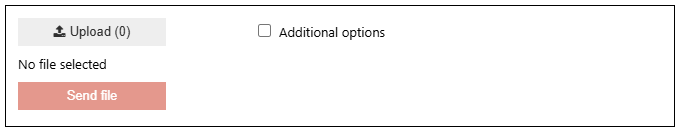


**In this case, I show what a return would look like, having requested additional options using a list to filter *restaurants* with a threshold of *0.75*.**  
*En este caso, muestro cómo sería un retorno, habiendo solicitado opciones adicionales usando una lista para filtrar **restaurantes** con un límite de **0.75**.*  
*En aquest cas, mostro com seria un retorn, havent demanat opcions addicionals utilitzant una llista per filtrar **restaurants** amb coeficient de **0.75**.*

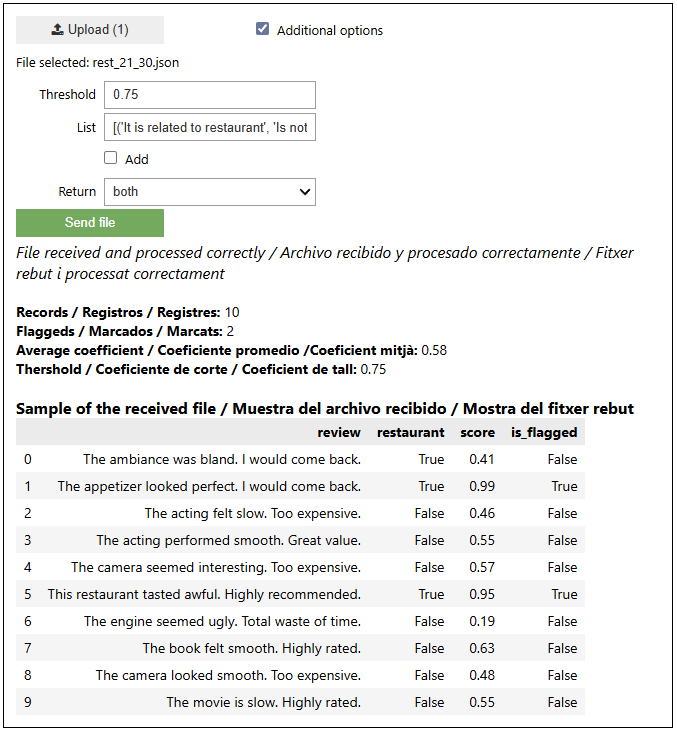


In [17]:
# en: Version with ipywidgets
# es: Versión con ipywidgets
# ca: Versió amb ipywidgets
pujar_ctl = ipyw.FileUpload(accept='.csv,.txt,.json', multiple=False)
fitxer_label = ipyw.Label(actualitzar_ctls(idiomaActual,"file", "SelectedNone"))
coef_ctl = ipyw.Text(value='', description=languages[idiomaActual]["threshold_desc"], placeholder=languages[idiomaActual]["threshold_placeholder"])
llista_ctl = ipyw.Text(value='', description=languages[idiomaActual]["llista_desc"], placeholder=languages[idiomaActual]["llista_placeholder"])
afegeix_ctl = ipyw.Checkbox(value=False, description=languages[idiomaActual]["add_desc"], layout=ipyw.Layout(display='none'))

retorn_ctl = ipyw.Dropdown(
    options=['score', 'is_flagged', 'both'],
    value='both',
    description=languages[idiomaActual]["retorn_desc"]
)

enviar_btn = ipyw.Button(description=languages[idiomaActual]["send_file_desc"],disabled=True, button_style="danger")
info2_ctl = ipyw.Output()

opcionsAddChk = ipyw.Checkbox(value=False, description=languages[idiomaActual]["opcions_ad_desc"])
opcionsAddBox = ipyw.VBox([
    coef_ctl,
    llista_ctl,
    afegeix_ctl,
    retorn_ctl
],layout=ipyw.Layout(display='none'))

def opcionsAddChk_canvia(change):
    if change.new:
        opcionsAddBox.layout.display = ''
    else:
        opcionsAddBox.layout.display = 'none'
        coef_ctl.value = ''
        llista_ctl.value = ''
        afegeix_ctl.value = False
        retorn_ctl.value = 'both'

opcionsAddChk.observe(opcionsAddChk_canvia, names='value')

fitxerBox = ipyw.HBox([
    pujar_ctl,
    opcionsAddChk,
])

def actualitzar_visibilitat_afegeix_ctl(change):
    valor = llista_ctl.value
    if not valor.strip():
        afegeix_ctl.layout.display = 'none'
        afegeix_ctl.value = False
    else:
        afegeix_ctl.layout.display = ''

llista_ctl.observe(actualitzar_visibilitat_afegeix_ctl, names='value')

# en: Update file label
# es: Actualizar etiqueta del archivo
# ca: Actualitzar etiqueta del fitxer
def actualitzar_nom_fitxer(change):
    if pujar_ctl.value:
        nom = pujar_ctl.value[0]['name']
        fitxer_label.value = actualitzar_ctls(idiomaActual,"file", "Selected", nom=nom)
        enviar_btn.disabled = False
        enviar_btn.button_style = "success"
    else:
        fitxer_label.value = actualitzar_ctls(idiomaActual,"file", "SelectedNone")
        enviar_btn.disabled = True
        enviar_btn.button_style = "danger"

pujar_ctl.observe(actualitzar_nom_fitxer, names='value')

def processar_fitxer(b):
    info2_ctl.clear_output()
    with info2_ctl:
        nom_fitxer = pujar_ctl.value[0]['name']
        contingut = pujar_ctl.value[0]['content']
        # en: To simulate writing to disk
        # es: Para simular la grabación en disco
        # ca: Per simular la gravació al disc

        f=io.BytesIO(contingut)

        # en: We prepare data and make the call
        # es: Preparamos datos y hacemos la llamada
        # ca: Preparem dades i fem la crida
        fitxer = {"fitxer": (nom_fitxer, f)}
        dades = {
            "thershold": None if coef_ctl.value.strip() == "" else float(coef_ctl.value.strip()),
            "retorn": retorn_ctl.value
        }
        if llista_ctl.value.strip():
            dades["laLlista"] = str(llista_ctl.value)
            dades["afegeix"] = afegeix_ctl.value

        try:
            display(HTML("<font size=3><i>Esperant resposta...</i></font>"))
            resposta = requests.post(laUrl+"totDeCop/",
                                     files=fitxer,
                                     data=dades,
                                     headers={"tokenId": "x001b3"})
        except Exception as e:
            clear_output()
            print(f"Connection error {e} / Error de conexión {e} /Error de connexió: {e}")
            return

        if resposta.ok:
            clear_output()
            display(HTML("<font size=3><i>File received and processed correctly / Archivo recibido y procesado correctamente / Fitxer rebut i processat correctament</i></font>"))
            # en: Since I know each of the returned values are in the header,
            #     I add them one by one
            #
            # es: Como sé que cada uno de los valores retornados está en la cabecera,
            #     los voy agregando uno a uno
            #
            # ca: Com se cadascun dels valors retornats i estan a la capcelera,
            #     els vaig agregant un a un
            
            cadena=f"<br><b>Records / Registros / Registres:</b> {resposta.headers.get('records')}<br>" 
            cadena+=f"<b>Flaggeds / Marcados / Marcats:</b> {resposta.headers.get('flaggeds')}<br>"
            cadena+=f"<b>Average coefficient / Coeficiente promedio /Coeficient mitjà:</b> {resposta.headers.get('average_coefficient')}<br>"
            cadena+=f"<b>Thershold / Coeficiente de corte / Coeficient de tall:</b> {resposta.headers.get('Thershold')}<br><br>"
            display(HTML(cadena))
            with open("data/evaluated.csv", "wb") as out_f:
                out_f.write(resposta.content)
            dfResposta = pd.read_csv("data/evaluated.csv")
            display(HTML("<font size=3><b>Sample of the received file " \
                + "/ Muestra del archivo recibido " \
                + "/ Mostra del fitxer rebut</b></font>"))
            display(dfResposta.head(10))
            info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl","evalfileok")
        else:
            clear_output()
            # en: How I know the value's in json format, I read 'em one by one from the `resposta` variable
            # es: Como sé que el valor está en formato json, los leo uno a uno de la variable `resposta`
            # ca: Com se que el valor està en format json, els llegeixo un a un de la variable `resposta`

            display(HTML(f"<font size=3><i>Error: {resposta.status_code}</i><br></font>"))
            cadena=""
            for key, value in resposta.json().items():
                cadena+=f"<b>{key}:</b> {value}<br>"
            display(HTML(cadena))
            info_ctl.value = actualitzar_ctls(idiomaActual,"info_lbl","evalfileerror")


enviar_btn.on_click(processar_fitxer)

# en: We show the widget
# es: Mostramos el widget
# ca: Mostrem el widget

display(ipyw.VBox([
    fitxerBox,
    fitxer_label,
    opcionsAddBox,
    enviar_btn,
    info2_ctl
    ],layout=ipyw.Layout(border="1px solid black",padding="10px",margin="10px")))

